In [34]:
# Análisis Exploratorio del Dataset Bank Marketing

!pip -q install ucimlrepo

In [35]:
from ucimlrepo import fetch_ucirepo

In [36]:
#Carga del dataset
bank_marketing = fetch_ucirepo(id=222)

In [37]:
datos = bank_marketing.data.features.copy()
etiquetas = bank_marketing.data.targets.copy()

In [38]:
etiquetas = etiquetas.iloc[:, 0]
etiquetas = etiquetas.map({"yes": 1, "no": 0})

df = datos.copy()
df["etiquetas"] = etiquetas

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,etiquetas
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,0
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,0
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,0
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,0


In [39]:
print("Columnas:")
print(df.columns)

print("\nDistribucion: ")
print(df["etiquetas"].value_counts())

print("\nDistribucion %: ")
print(df["etiquetas"].value_counts(normalize=True) * 100)

Columnas:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'etiquetas'],
      dtype='object')

Distribucion: 
etiquetas
0    39922
1     5289
Name: count, dtype: int64

Distribucion %: 
etiquetas
0    88.30152
1    11.69848
Name: proportion, dtype: float64


# Exploración


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  etiquetas    45211 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 5.9+ MB


In [41]:
# Revisión de valores faltantes
faltantes = df.isnull().sum().sort_values(ascending=False)
faltantes[faltantes > 0]

,0
poutcome,36959
contact,13020
education,1857
job,288


In [42]:
# Importación de librerías adicionales para exploración y modelado
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Configuración visual uniforme para todos los gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 12

print('Librerías cargadas.')

Librerías cargadas.


# Estadística descriptiva

In [43]:
# Separar variables numéricas y categóricas del dataframe principal
vars_num = df.select_dtypes(include=['int64', 'float64']).columns.drop('etiquetas').tolist()
vars_cat = df.select_dtypes(include='object').columns.tolist()

print(f'Variables numéricas ({len(vars_num)}): {vars_num}')
print(f'Variables categóricas ({len(vars_cat)}): {vars_cat}')

Variables numéricas (7): ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [44]:
# Estadística descriptiva extendida: media, mediana, desv. estándar, skewness y kurtosis
desc = df[vars_num].agg(['mean', 'median', 'std', 'min', 'max', 'skew', 'kurt']).T.round(3)
desc.columns = ['Media', 'Mediana', 'Desv. Estándar', 'Mínimo', 'Máximo', 'Asimetría', 'Curtosis']
print('Estadística descriptiva extendida de variables numéricas:')
desc

Estadística descriptiva extendida de variables numéricas:


,Media,Mediana,Desv. Estándar,Mínimo,Máximo,Asimetría,Curtosis
age,40.936,39.0,10.619,18.0,95.0,0.685,0.320
balance,1362.272,448.0,3044.766,-8019.0,102127.0,8.360,140.752
day_of_week,15.806,16.0,8.322,1.0,31.0,0.093,-1.060
duration,258.163,180.0,257.528,0.0,4918.0,3.144,18.154
campaign,2.764,2.0,3.098,1.0,63.0,4.899,39.250
pdays,40.198,-1.0,100.129,-1.0,871.0,2.616,6.935
previous,0.580,0.0,2.303,0.0,275.0,41.846,4506.861


In [45]:
# Frecuencias y proporciones de variables categóricas
for col in vars_cat:
    conteo = df[col].value_counts()
    pct    = (conteo / len(df) * 100).round(2)
    tabla  = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': pct})
    print(f'\n── {col} ──')
    print(tabla.to_string())


── job ──
               Cantidad  Porcentaje (%)
job                                    
blue-collar        9732           21.53
management         9458           20.92
technician         7597           16.80
admin.             5171           11.44
services           4154            9.19
retired            2264            5.01
self-employed      1579            3.49
entrepreneur       1487            3.29
unemployed         1303            2.88
housemaid          1240            2.74
student             938            2.07

── marital ──
          Cantidad  Porcentaje (%)
marital                           
married      27214           60.19
single       12790           28.29
divorced      5207           11.52

── education ──
           Cantidad  Porcentaje (%)
education                          
secondary     23202           51.32
tertiary      13301           29.42
primary        6851           15.15

── default ──
         Cantidad  Porcentaje (%)
default                          

# Manejo de Datos Faltantes Implícitos

In [46]:
# El dataset no tiene NaN reales, pero usa 'unknown' como valor faltante implícito
print('Variables con valor "unknown":')
for col in vars_cat:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col}: {n} registros ({n/len(df)*100:.2f}%)')

print('\nEstrategia adoptada: reemplazar "unknown" por la moda de cada variable.')
df_limpio = df.copy()
for col in vars_cat:
    if (df_limpio[col] == 'unknown').sum() > 0:
        moda = df_limpio[df_limpio[col] != 'unknown'][col].mode()[0]
        df_limpio[col] = df_limpio[col].replace('unknown', moda)
        print(f'  {col} -> moda = "{moda}"')

Variables con valor "unknown":

Estrategia adoptada: reemplazar "unknown" por la moda de cada variable.


# Detección de outliers

In [47]:
# Detección de outliers usando el criterio IQR (Rango Intercuartílico)
# Un valor es outlier si está por debajo de Q1 - 1.5*IQR o por encima de Q3 + 1.5*IQR
print('Outliers detectados por variable (criterio IQR):')
resumen_outliers = []
for col in vars_num:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_out = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
    resumen_outliers.append({'Variable': col, 'Outliers': n_out,
                             'Porcentaje (%)': round(n_out / len(df) * 100, 2),
                             'Límite inferior': round(limite_inf, 2),
                             'Límite superior': round(limite_sup, 2)})

pd.DataFrame(resumen_outliers).set_index('Variable')

Outliers detectados por variable (criterio IQR):


,Outliers,Porcentaje (%),Límite inferior,Límite superior
Variable,,,,
age,487,1.08,10.5,70.5
balance,4729,10.46,-1962.0,3462.0
day_of_week,0,0.00,-11.5,40.5
duration,3235,7.16,-221.0,643.0
campaign,3064,6.78,-2.0,6.0
pdays,8257,18.26,-1.0,-1.0
previous,8257,18.26,0.0,0.0


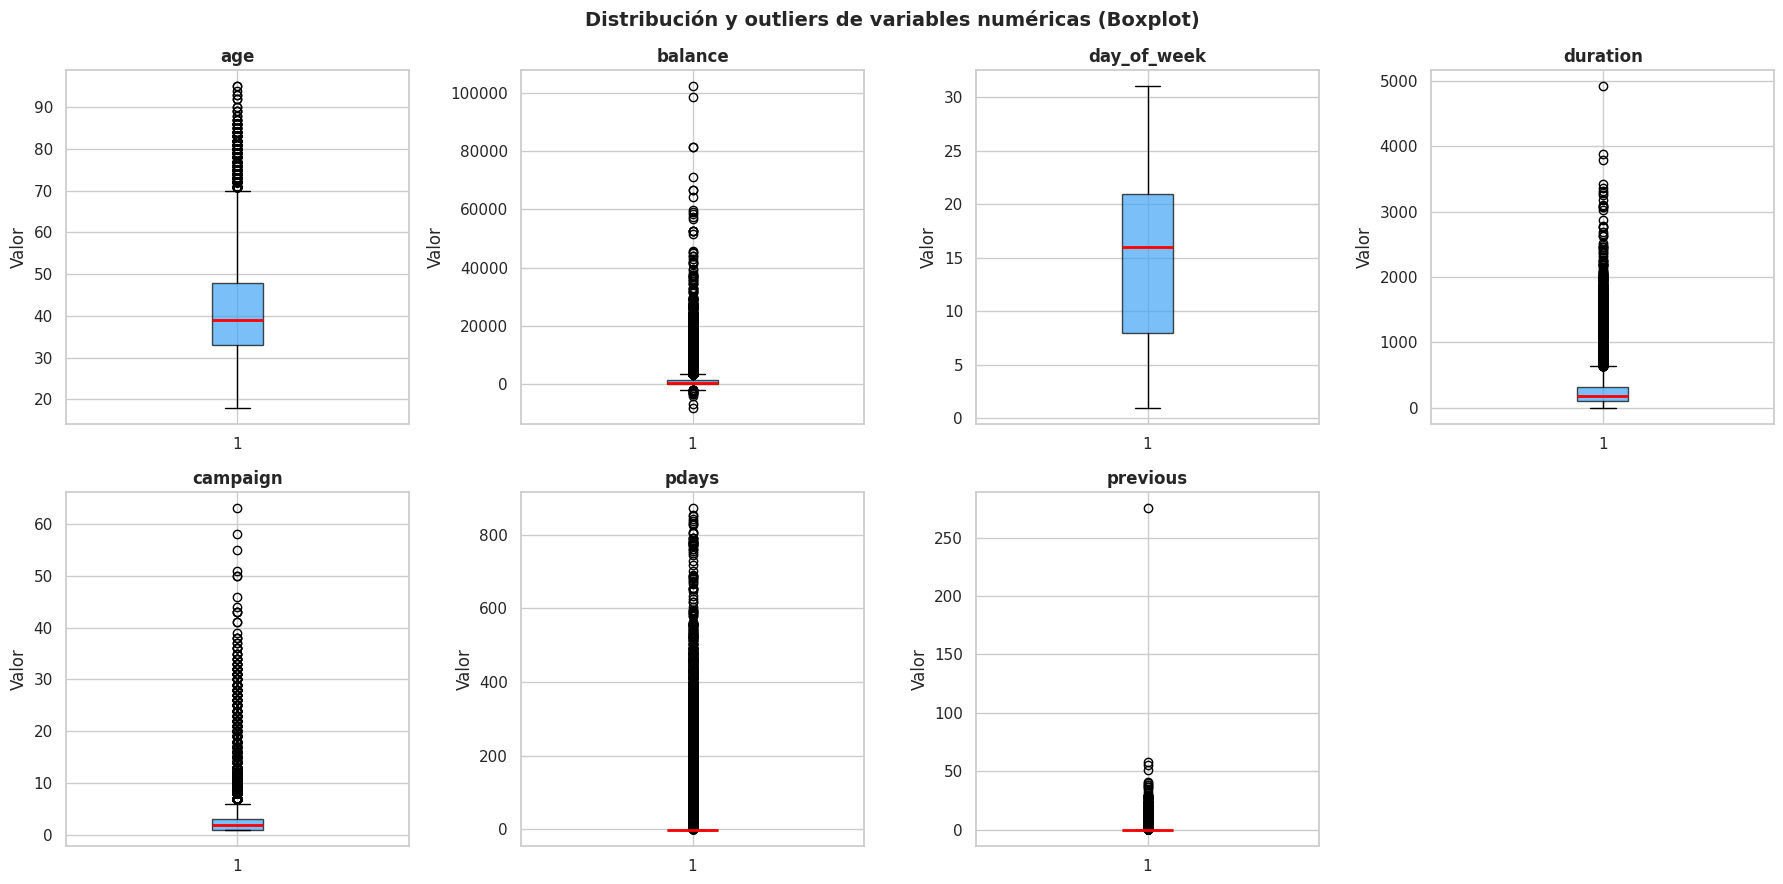

In [48]:
# Boxplots para visualizar la distribución y outliers de variables numéricas
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(vars_num):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#42A5F5', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Valor')

# Ocultar subplots vacíos
for j in range(len(vars_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución y outliers de variables numéricas (Boxplot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualización de Distribuciones

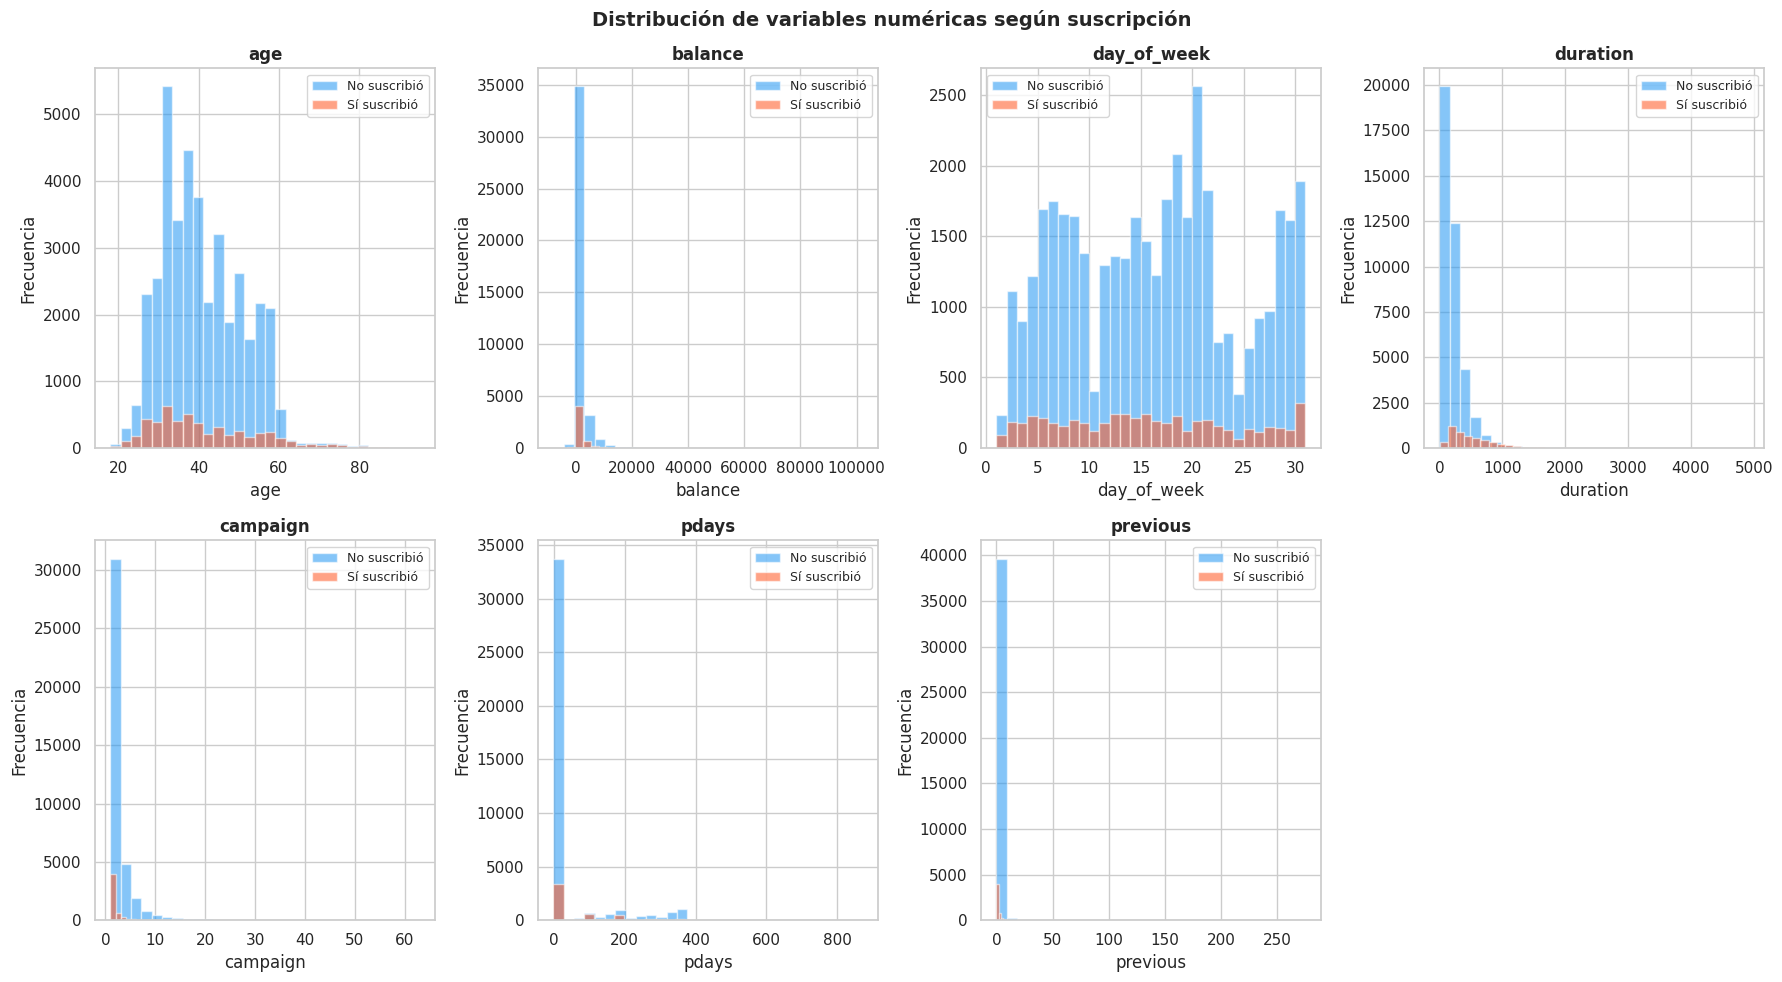

In [49]:
# Histogramas de variables numéricas separados por clase (suscribió / no suscribió)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

colores = {0: '#2196F3', 1: '#FF5722'}
etiqueta_nombre = {0: 'No suscribió', 1: 'Sí suscribió'}

for i, col in enumerate(vars_num):
    for val, color in colores.items():
        subset = df[df['etiquetas'] == val][col]
        axes[i].hist(subset, bins=30, alpha=0.55, color=color,
                     label=etiqueta_nombre[val], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=9)

for j in range(len(vars_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas según suscripción', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

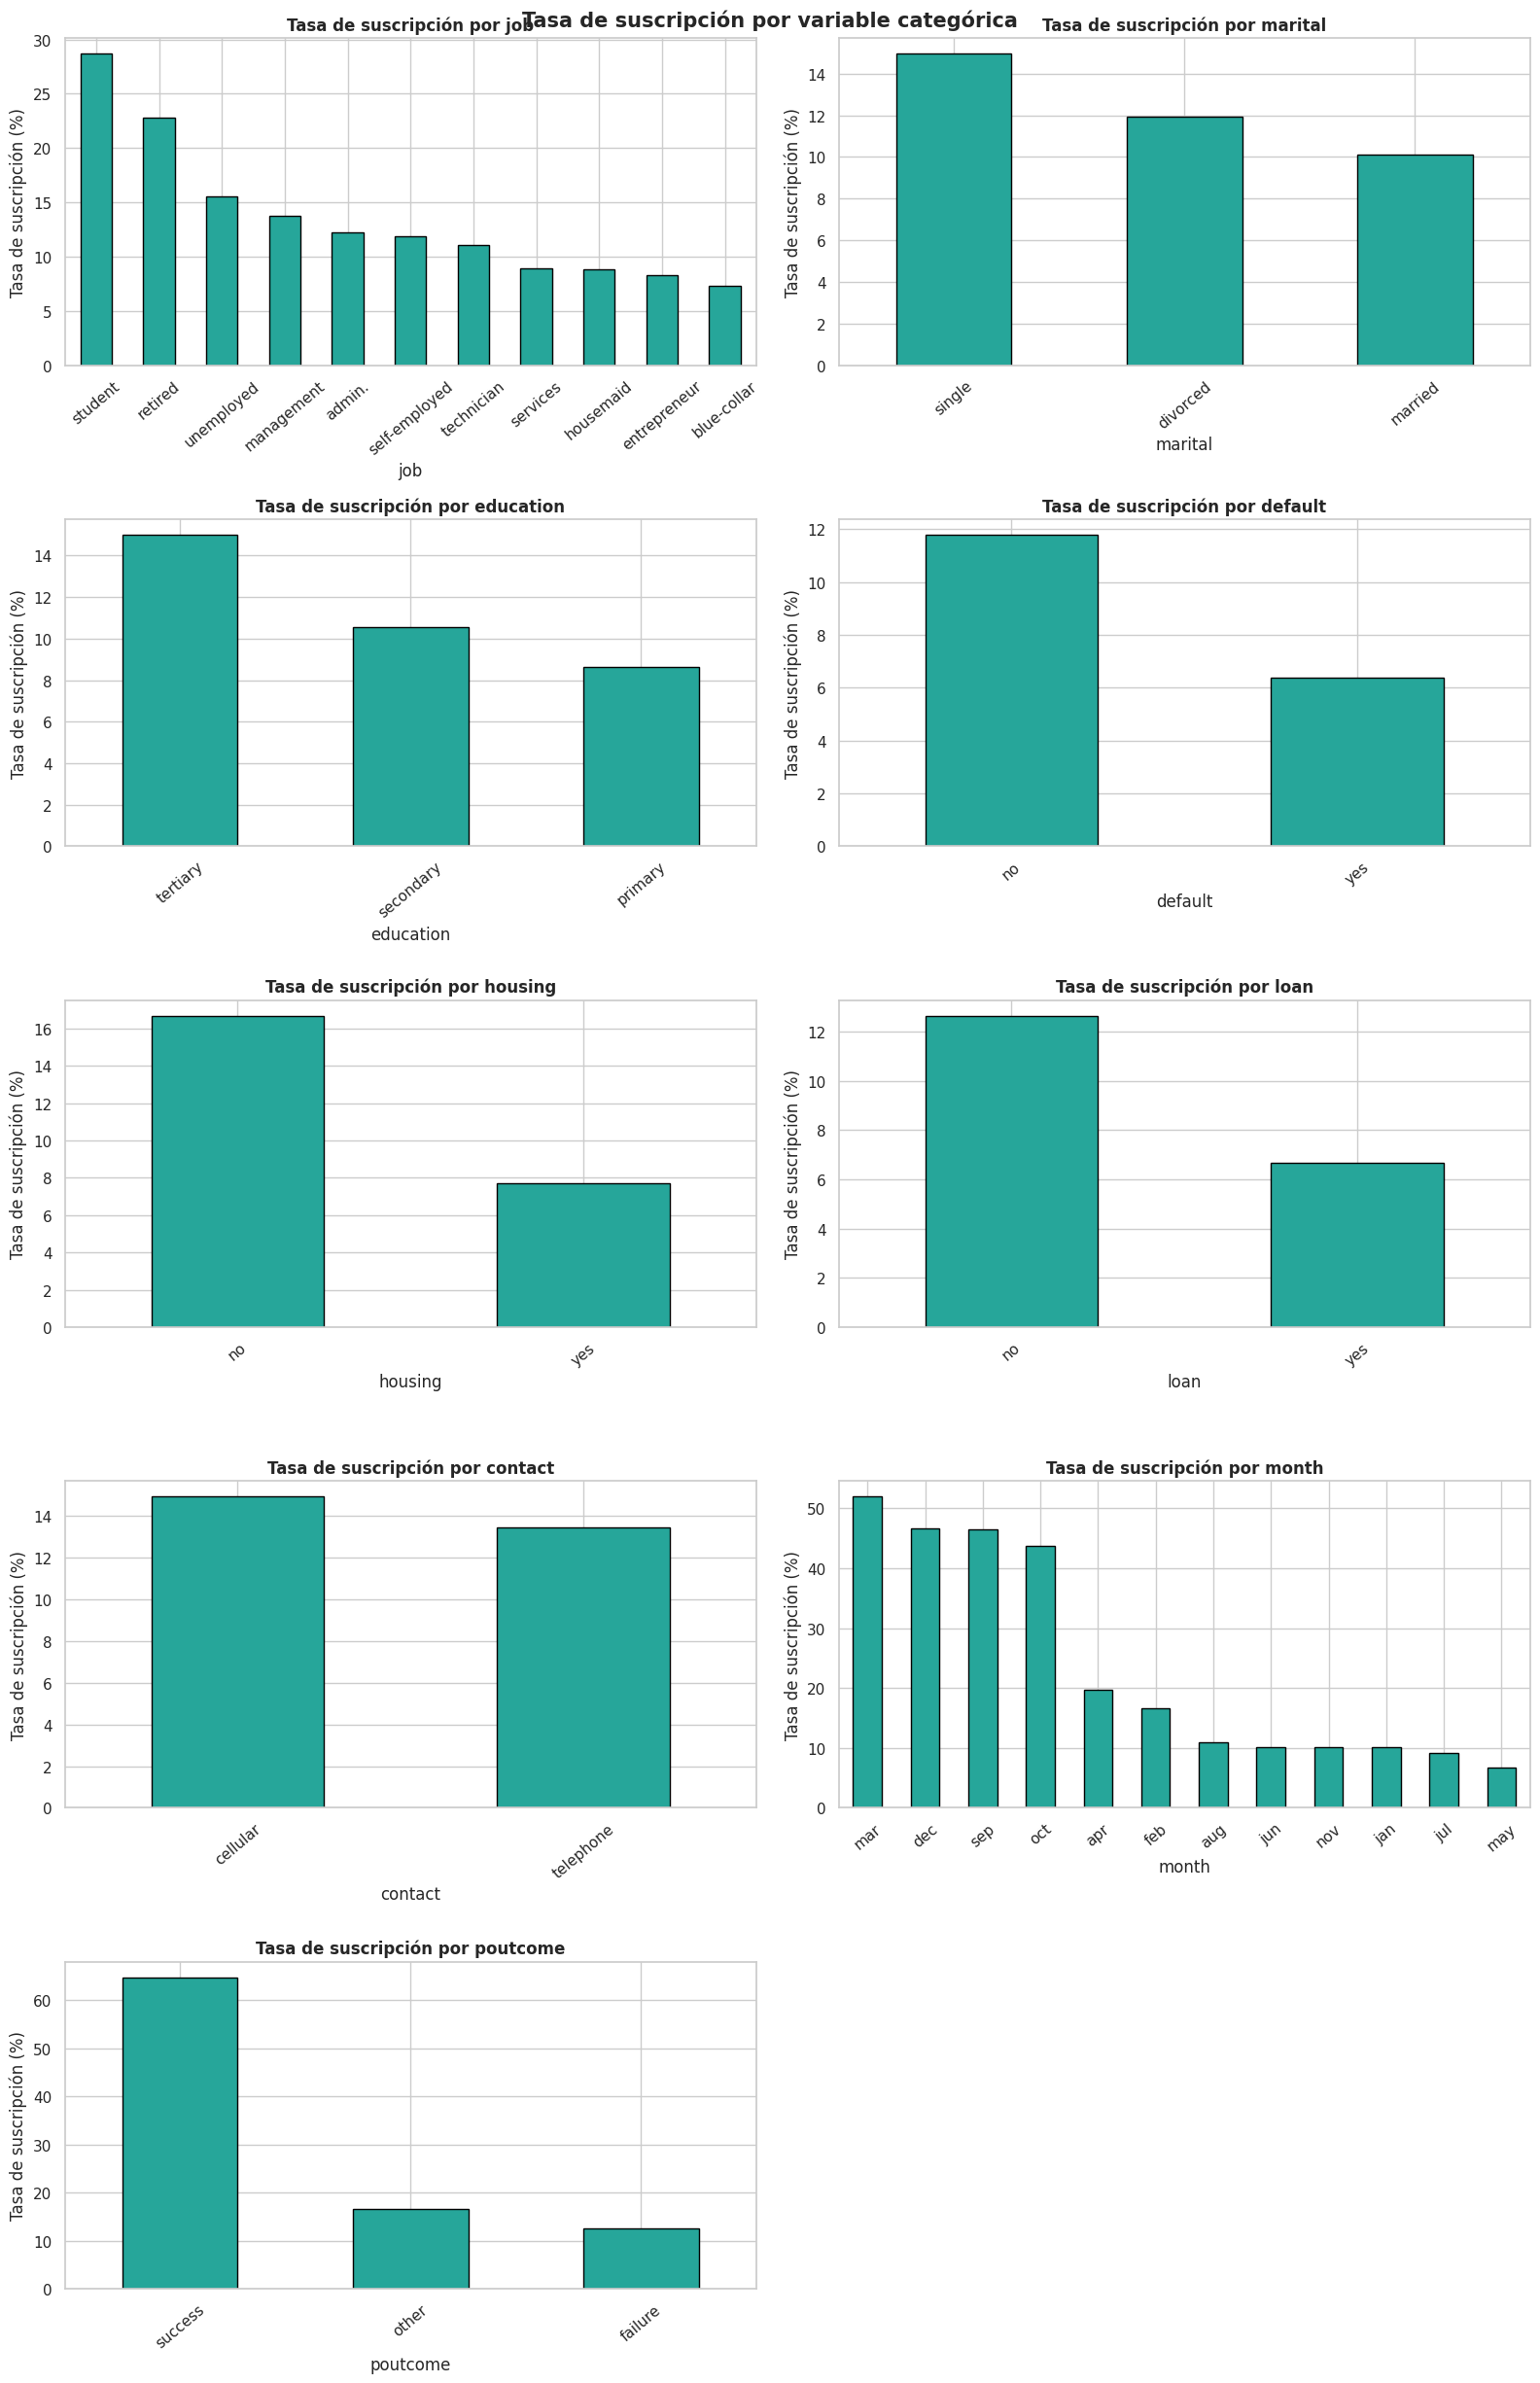

In [50]:
import math

# Tasa de suscripción por cada variable categórica
n_cats = len(vars_cat)
ncols = 2 # Number of columns for the subplots
nrows = math.ceil(n_cats / ncols) # Calculate the number of rows needed

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows)) # Adjust figsize dynamically
axes = axes.flatten()

for i, col in enumerate(vars_cat):
    tasa = df.groupby(col)['etiquetas'].mean().sort_values(ascending=False) * 100
    tasa.plot(kind='bar', ax=axes[i], color='#26A69A', edgecolor='black')
    axes[i].set_title(f'Tasa de suscripción por {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Tasa de suscripción (%)')
    axes[i].tick_params(axis='x', rotation=40)

# Hide any empty subplots if nrows * ncols > n_cats
for j in range(n_cats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasa de suscripción por variable categórica', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('tasa_por_categorica.png', dpi=150, bbox_inches='tight')
plt.show()

# Modelado Predictivo


In [51]:
def preparar_pipeline(X_train, modelo):
    columnas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
    columnas_categoricas = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

    preprocesamiento = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), columnas_numericas),
            ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
        ]
    )

    pipeline = Pipeline(
        steps=[
            ("prep", preprocesamiento),
            ("model", modelo)
        ]
    )

    return pipeline

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    PrecisionRecallDisplay, RocCurveDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [53]:
def evaluar_experimento(nombre_experimento, X_data, y_data):
    # Separación train / validación / test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_data, y_data,
        test_size=0.20,
        random_state=42,
        stratify=y_data
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=0.25,
        random_state=42,
        stratify=y_train_val
    )

    modelos = {
        "Regresion_Logistica": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ),
        "Random_Forest": RandomForestClassifier(
            n_estimators=250,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    }

    resultados = []
    objetos = {}

    for nombre_modelo, modelo in modelos.items():
        pipe = preparar_pipeline(X_train, modelo)
        pipe.fit(X_train, y_train)

        # Probabilidades en validación
        proba_val = pipe.predict_proba(X_val)[:, 1]

        # Buscar umbral que maximice F1 en validación
        umbrales = np.arange(0.10, 0.91, 0.01)
        f1s = []

        for t in umbrales:
            pred_val = (proba_val >= t).astype(int)
            f1s.append(f1_score(y_val, pred_val))

        mejor_umbral = umbrales[np.argmax(f1s)]

        # Evaluación final en test
        proba_test = pipe.predict_proba(X_test)[:, 1]
        pred_test = (proba_test >= mejor_umbral).astype(int)

        resultados.append({
            "experimento": nombre_experimento,
            "modelo": nombre_modelo,
            "umbral": mejor_umbral,
            "accuracy": accuracy_score(y_test, pred_test),
            "precision": precision_score(y_test, pred_test),
            "recall": recall_score(y_test, pred_test),
            "f1": f1_score(y_test, pred_test),
            "roc_auc": roc_auc_score(y_test, proba_test),
            "pr_auc": average_precision_score(y_test, proba_test)
        })

        objetos[(nombre_experimento, nombre_modelo)] = {
            "pipeline": pipe,
            "X_test": X_test,
            "y_test": y_test,
            "proba_test": proba_test,
            "pred_test": pred_test,
            "umbral": mejor_umbral
        }

    return pd.DataFrame(resultados), objetos

In [54]:
datos_sin_duration = datos.drop(columns=["duration"], errors="ignore")

resultados_sin_duration, objetos_sin_duration = evaluar_experimento(
    "Accionable_sin_duration",
    datos_sin_duration,
    etiquetas
)

resultados_sin_duration

,experimento,modelo,umbral,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Accionable_sin_duration,Regresion_Logistica,0.63,0.865974,0.430880,0.453686,0.441989,0.771270,0.408707
1,Accionable_sin_duration,Random_Forest,0.57,0.871835,0.457021,0.507561,0.480967,0.799862,0.448155


In [55]:
resultados_con_duration, objetos_con_duration = evaluar_experimento(
    "Benchmark_con_duration",
    datos,
    etiquetas
)

resultados_con_duration

,experimento,modelo,umbral,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Benchmark_con_duration,Regresion_Logistica,0.63,0.877695,0.484752,0.721172,0.579787,0.907926,0.536940
1,Benchmark_con_duration,Random_Forest,0.60,0.889307,0.519038,0.734405,0.608219,0.925421,0.607346


# Comparación de Modelos

In [56]:
resultados = pd.concat(
    [resultados_sin_duration, resultados_con_duration],
    ignore_index=True
)

resultados = resultados.sort_values("pr_auc", ascending=False)
resultados

,experimento,modelo,umbral,accuracy,precision,recall,f1,roc_auc,pr_auc
3,Benchmark_con_duration,Random_Forest,0.60,0.889307,0.519038,0.734405,0.608219,0.925421,0.607346
2,Benchmark_con_duration,Regresion_Logistica,0.63,0.877695,0.484752,0.721172,0.579787,0.907926,0.536940
1,Accionable_sin_duration,Random_Forest,0.57,0.871835,0.457021,0.507561,0.480967,0.799862,0.448155
0,Accionable_sin_duration,Regresion_Logistica,0.63,0.865974,0.430880,0.453686,0.441989,0.771270,0.408707


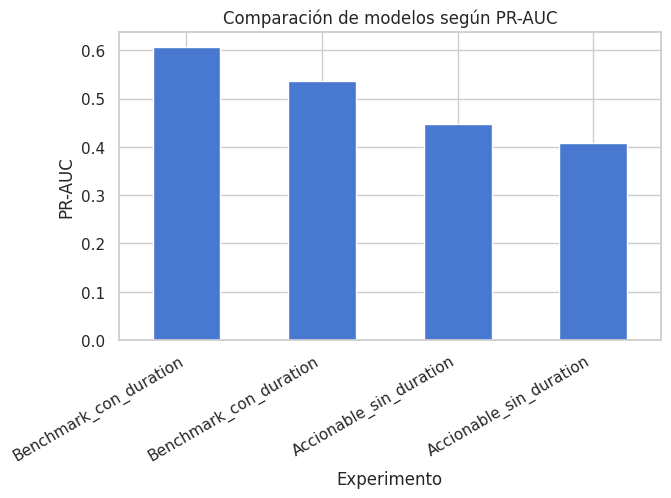

In [57]:
# Gráfico simple de comparación
resultados_plot = resultados.set_index("experimento")["pr_auc"]

resultados_plot.plot(kind="bar", figsize=(7,4))
plt.title("Comparación de modelos según PR-AUC")
plt.ylabel("PR-AUC")
plt.xlabel("Experimento")
plt.xticks(rotation=30, ha="right")
plt.show()

# Mapa de calor de correlaciones

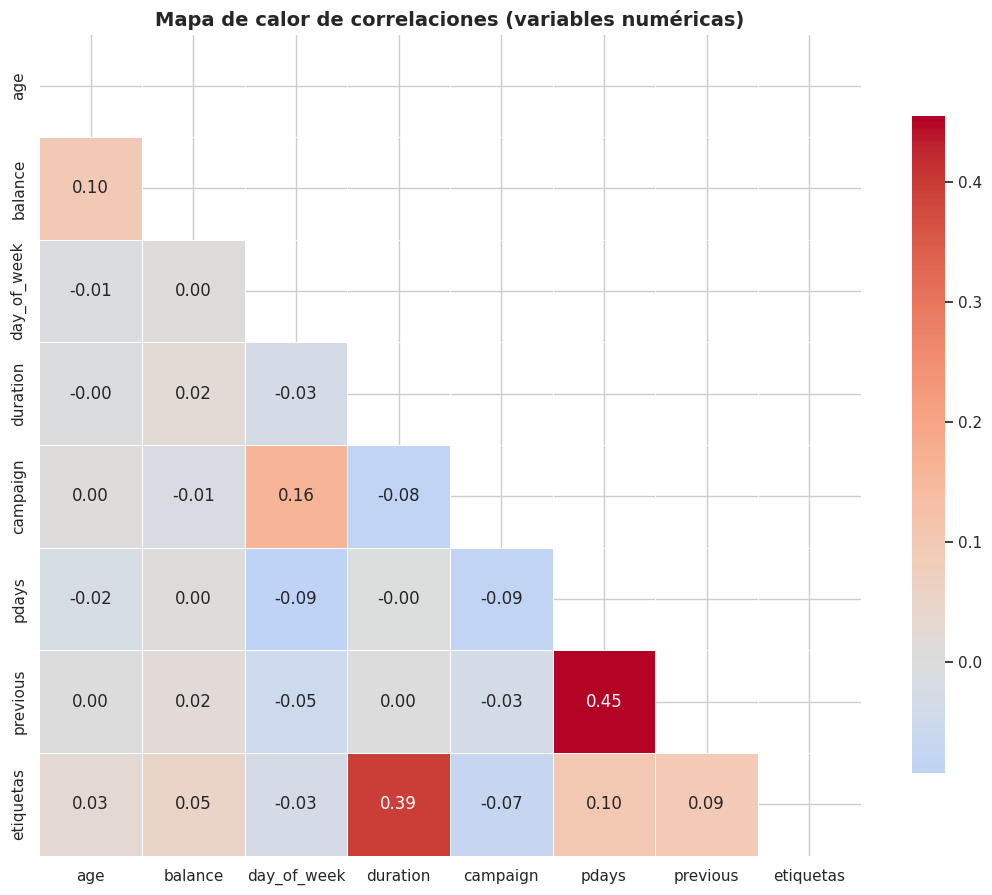


Correlación con la variable objetivo (etiquetas):
duration       0.395
pdays          0.104
previous       0.093
balance        0.053
age            0.025
day_of_week   -0.028
campaign      -0.073
Name: etiquetas, dtype: float64


In [58]:
# Mapa de calor de correlación entre variables numéricas + variable objetivo
cols_corr = vars_num + ['etiquetas']
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(11, 9))
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mostrar solo triángulo inferior
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mascara, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Mapa de calor de correlaciones (variables numéricas)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Ranking de correlación con la variable objetivo
print('\nCorrelación con la variable objetivo (etiquetas):')
print(corr_matrix['etiquetas'].drop('etiquetas').sort_values(ascending=False).round(3))

# Selección de características relevantes

In [59]:
# Identificar variables numéricas con correlación significativa con el objetivo
umbral = 0.05
corr_objetivo = corr_matrix['etiquetas'].drop('etiquetas')
features_relevantes = corr_objetivo[abs(corr_objetivo) >= umbral].sort_values(ascending=False)

print(f'Variables numéricas con |correlación| >= {umbral} con la variable objetivo:')
for var, val in features_relevantes.items():
    print(f'  {var}: {val:.3f}')

Variables numéricas con |correlación| >= 0.05 con la variable objetivo:
  duration: 0.395
  pdays: 0.104
  previous: 0.093
  balance: 0.053
  campaign: -0.073


# Curvas ROC-AUC y Precisión-Recall

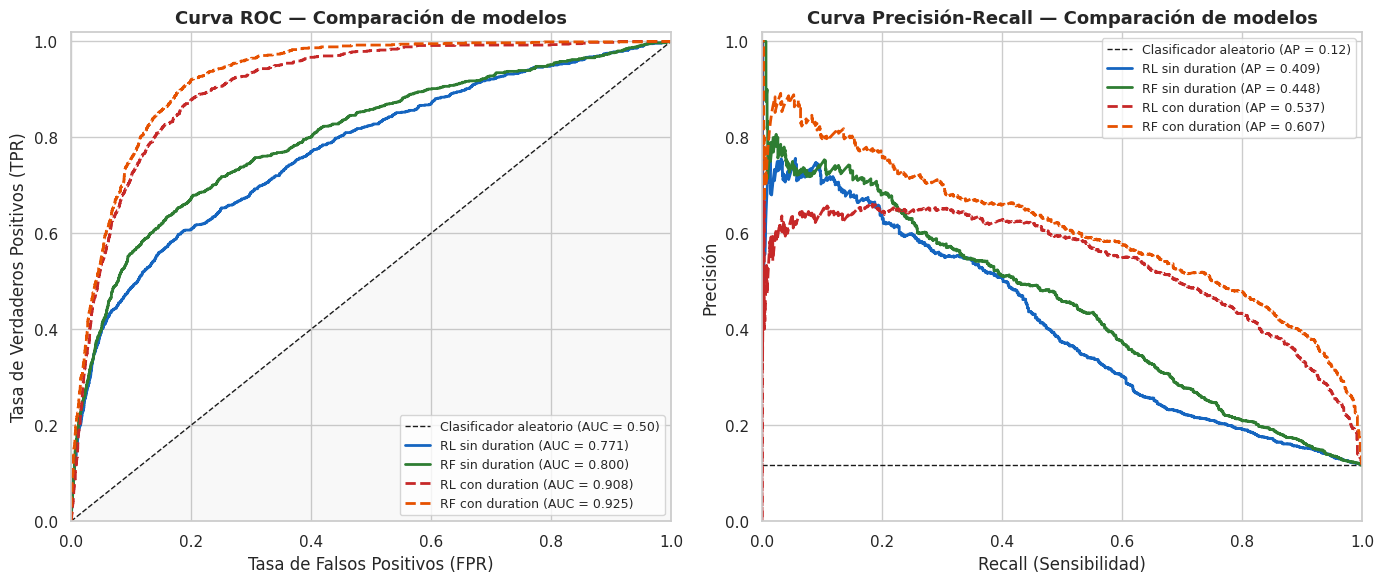

In [60]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ── Curvas ROC para todos los modelos y experimentos ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Colores y estilos para distinguir modelos
estilos = {
    ('Accionable_sin_duration', 'Regresion_Logistica'): ('#1565C0', '-',  'RL sin duration'),
    ('Accionable_sin_duration', 'Random_Forest'):        ('#2E7D32', '-',  'RF sin duration'),
    ('Benchmark_con_duration',  'Regresion_Logistica'): ('#C62828', '--', 'RL con duration'),
    ('Benchmark_con_duration',  'Random_Forest'):        ('#E65100', '--', 'RF con duration'),
}

# Combinar todos los objetos de ambos experimentos
todos_objetos = {**objetos_sin_duration, **objetos_con_duration}

# Gráfico 1: Curva ROC
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio (AUC = 0.50)')

for (exp, mod), color_ls_label in estilos.items():
    color, ls, label = color_ls_label
    obj = todos_objetos[(exp, mod)]
    fpr, tpr, _ = roc_curve(obj['y_test'], obj['proba_test'])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
                 label=f'{label} (AUC = {roc_auc:.3f})')

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.02])
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
axes[0].set_title('Curva ROC — Comparación de modelos', fontweight='bold', fontsize=13)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

# Gráfico 2: Curva Precisión-Recall
# Línea base: proporción de la clase positiva
baseline = etiquetas.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1,
                label=f'Clasificador aleatorio (AP = {baseline:.2f})')

for (exp, mod), color_ls_label in estilos.items():
    color, ls, label = color_ls_label
    obj = todos_objetos[(exp, mod)]
    precision, recall, _ = precision_recall_curve(obj['y_test'], obj['proba_test'])
    ap = average_precision_score(obj['y_test'], obj['proba_test'])
    axes[1].plot(recall, precision, color=color, linestyle=ls, linewidth=2,
                 label=f'{label} (AP = {ap:.3f})')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.02])
axes[1].set_xlabel('Recall (Sensibilidad)', fontsize=12)
axes[1].set_ylabel('Precisión', fontsize=12)
axes[1].set_title('Curva Precisión-Recall — Comparación de modelos', fontweight='bold', fontsize=13)
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

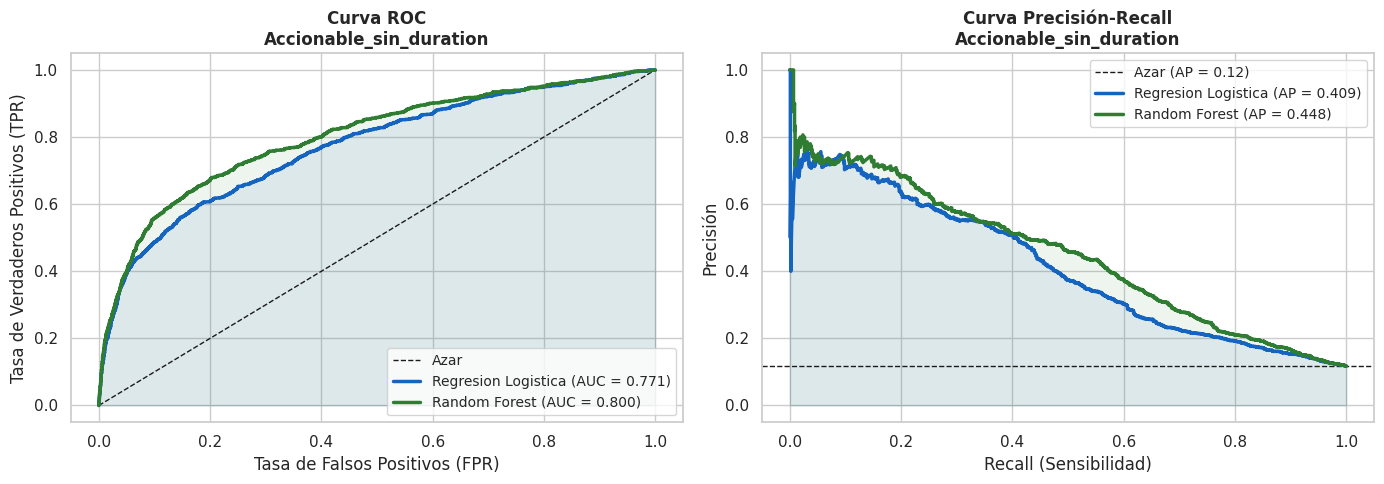

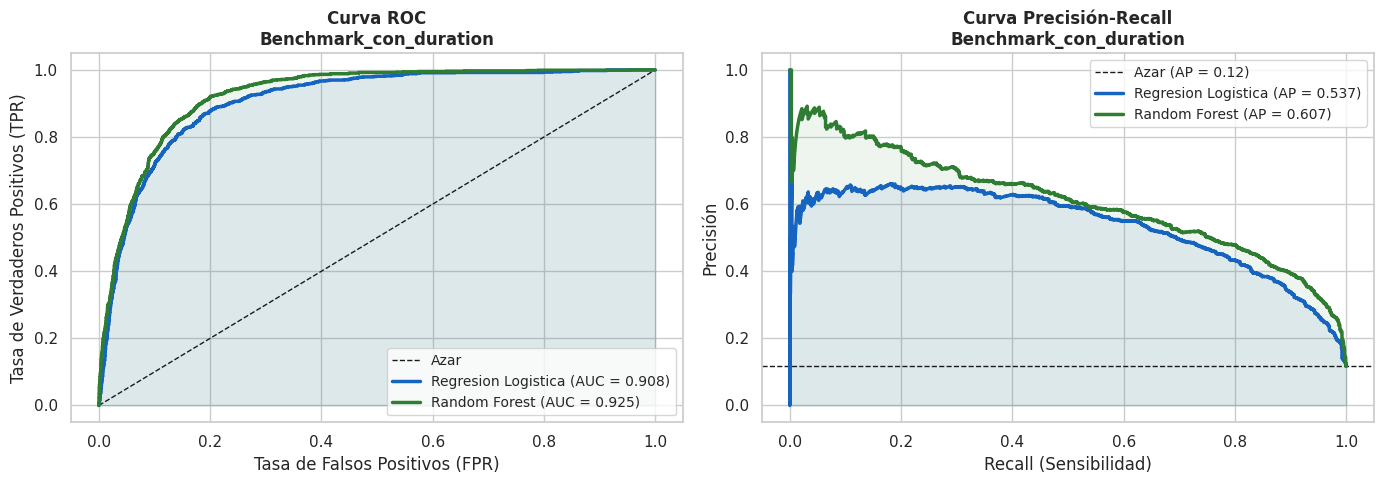

In [61]:
# ── Curvas ROC por separado: un gráfico por experimento ──
experimentos = {
    'Accionable_sin_duration': objetos_sin_duration,
    'Benchmark_con_duration':  objetos_con_duration,
}

for nombre_exp, objetos_exp in experimentos.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar')
    colores_mod = {'Regresion_Logistica': '#1565C0', 'Random_Forest': '#2E7D32'}

    for nombre_mod, color in colores_mod.items():
        obj = objetos_exp.get((nombre_exp, nombre_mod))
        if obj is None:
            continue
        fpr, tpr, _ = roc_curve(obj['y_test'], obj['proba_test'])
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                     label=f'{nombre_mod.replace("_", " ")} (AUC = {roc_auc:.3f})')
        # Sombreado del área bajo la curva
        axes[0].fill_between(fpr, tpr, alpha=0.08, color=color)

    axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axes[0].set_title(f'Curva ROC\n{nombre_exp}', fontweight='bold')
    axes[0].legend(loc='lower right', fontsize=10)

    # Precisión-Recall
    baseline = etiquetas.mean()
    axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1,
                    label=f'Azar (AP = {baseline:.2f})')

    for nombre_mod, color in colores_mod.items():
        obj = objetos_exp.get((nombre_exp, nombre_mod))
        if obj is None:
            continue
        precision, recall, _ = precision_recall_curve(obj['y_test'], obj['proba_test'])
        ap = average_precision_score(obj['y_test'], obj['proba_test'])
        axes[1].plot(recall, precision, color=color, linewidth=2.5,
                     label=f'{nombre_mod.replace("_", " ")} (AP = {ap:.3f})')
        axes[1].fill_between(recall, precision, alpha=0.08, color=color)

    axes[1].set_xlabel('Recall (Sensibilidad)')
    axes[1].set_ylabel('Precisión')
    axes[1].set_title(f'Curva Precisión-Recall\n{nombre_exp}', fontweight='bold')
    axes[1].legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'roc_pr_{nombre_exp}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [62]:
# ── Tabla resumen de métricas AUC de todos los modelos ──
filas = []
for (exp, mod), obj in todos_objetos.items():
    roc_auc_val = auc(*roc_curve(obj['y_test'], obj['proba_test'])[:2])
    ap_val      = average_precision_score(obj['y_test'], obj['proba_test'])
    filas.append({
        'Experimento': exp,
        'Modelo':      mod.replace('_', ' '),
        'ROC-AUC':     round(roc_auc_val, 4),
        'PR-AUC (AP)': round(ap_val, 4),
    })

tabla_auc = pd.DataFrame(filas).sort_values('ROC-AUC', ascending=False)
print('Resumen de métricas AUC:')
tabla_auc

Resumen de métricas AUC:


,Experimento,Modelo,ROC-AUC,PR-AUC (AP)
3,Benchmark_con_duration,Random Forest,0.9254,0.6073
2,Benchmark_con_duration,Regresion Logistica,0.9079,0.5369
1,Accionable_sin_duration,Random Forest,0.7999,0.4482
0,Accionable_sin_duration,Regresion Logistica,0.7713,0.4087


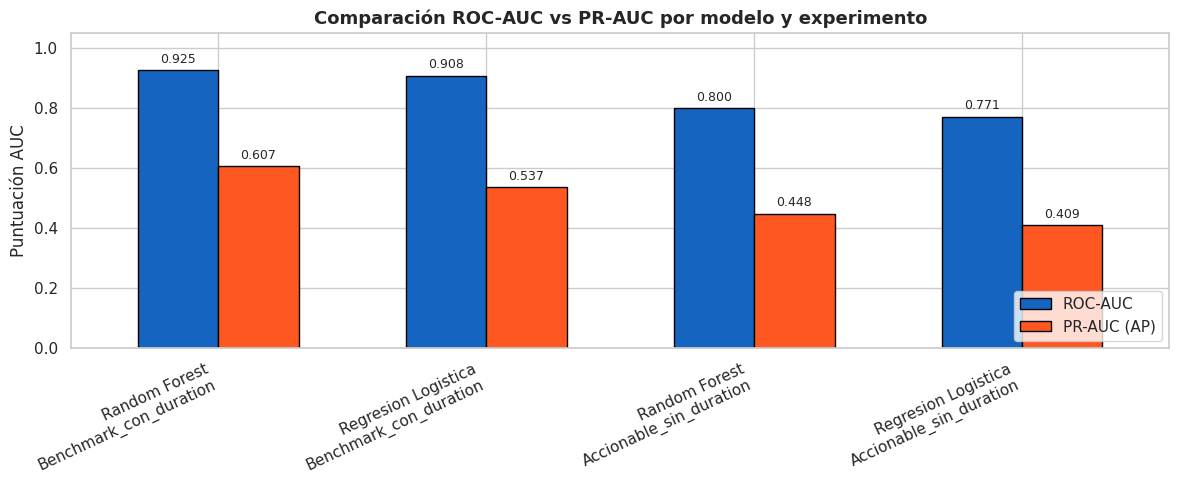

In [63]:
# ── Gráfico de barras comparativo: ROC-AUC vs PR-AUC ──
tabla_auc_plot = tabla_auc.copy()
tabla_auc_plot['Modelo_Exp'] = tabla_auc_plot['Modelo'] + '\n' + tabla_auc_plot['Experimento']
tabla_auc_plot = tabla_auc_plot.set_index('Modelo_Exp')[['ROC-AUC', 'PR-AUC (AP)']]

ax = tabla_auc_plot.plot(kind='bar', figsize=(12, 5), color=['#1565C0', '#FF5722'],
                          edgecolor='black', width=0.6)

# Agregar etiquetas de valor sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.title('Comparación ROC-AUC vs PR-AUC por modelo y experimento', fontweight='bold', fontsize=13)
plt.ylabel('Puntuación AUC')
plt.xlabel('')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('comparacion_auc.png', dpi=150, bbox_inches='tight')
plt.show()